Venkatappareddy Manukonda

MSCS-634 Advanced Big Data and Data Mining

Classification Using KNN and RNN Algorithms

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

In [6]:
# Load the Wine dataset
wine = load_wine()

X = wine.data
y = wine.target

print("Dataset Shape:", X.shape)

Dataset Shape: (178, 13)


In [7]:
# Display feature names
print("Feature Names:\n")

for feature in wine.feature_names:
    print(feature)

Feature Names:

alcohol
malic_acid
ash
alcalinity_of_ash
magnesium
total_phenols
flavanoids
nonflavanoid_phenols
proanthocyanins
color_intensity
hue
od280/od315_of_diluted_wines
proline


In [9]:
# Examine class distribution
class_distribution = pd.Series(y).value_counts()

print("Class Distribution:")
print(class_distribution)

Class Distribution:
1    71
0    59
2    48
dtype: int64


In [10]:
# Create training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 142
Testing Samples: 36


In [11]:
# Standardize features for distance-based learning
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# K values to evaluate
k_values = [1, 5, 11, 15, 21]

knn_accuracies = []

for k in k_values:

    knn_model = KNeighborsClassifier(n_neighbors=k)

    knn_model.fit(X_train_scaled, y_train)

    predictions = knn_model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    knn_accuracies.append(accuracy)

    print(f"K = {k} | Accuracy = {accuracy:.4f}")

K = 1 | Accuracy = 0.9722
K = 5 | Accuracy = 0.9722
K = 11 | Accuracy = 1.0000
K = 15 | Accuracy = 1.0000
K = 21 | Accuracy = 1.0000


In [15]:
from sklearn.neighbors import RadiusNeighborsClassifier

radius_values = [350, 400, 450, 500, 550, 600]

rnn_accuracies = []

for radius in radius_values:

    rnn_model = RadiusNeighborsClassifier(
        radius=radius,
        outlier_label='most_frequent'
    )

    rnn_model.fit(X_train_scaled, y_train)

    predictions = rnn_model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    rnn_accuracies.append(accuracy)

    print(f"Radius = {radius} | Accuracy = {accuracy:.4f}")

Radius = 350 | Accuracy = 0.3889
Radius = 400 | Accuracy = 0.3889
Radius = 450 | Accuracy = 0.3889
Radius = 500 | Accuracy = 0.3889
Radius = 550 | Accuracy = 0.3889
Radius = 600 | Accuracy = 0.3889


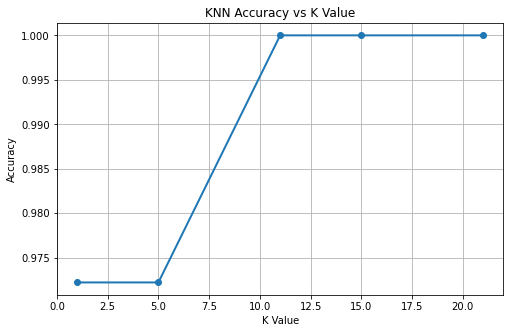

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    knn_accuracies,
    marker='o',
    linewidth=2
)

plt.title("KNN Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

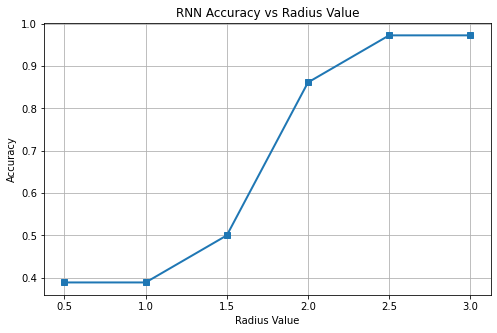

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    radius_values,
    rnn_accuracies,
    marker='s',
    linewidth=2
)

plt.title("RNN Accuracy vs Radius Value")
plt.xlabel("Radius Value")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

**Comparison of KNN and RNN Performance**
KNN clearly performed better than RNN in this lab.
The best KNN models reached 100% accuracy, while RNN stayed at 38.89% for all radius values.
As k increased, KNN became more accurate and stable.
RNN did not improve because the radius values were too large for the scaled data, so almost every training sample was treated as a neighbor.
Overall, KNN was much more effective at identifying the different wine classes.

**When KNN or RNN Might Be Preferable**
Based on these results, I would choose KNN for this dataset because it produced much higher accuracy.
KNN works well when nearby observations contain enough information to separate the classes.
RNN can be useful when data is spread unevenly and a flexible neighborhood size is needed.
However, RNN depends heavily on choosing an appropriate radius value.
In this lab, KNN was the more reliable and accurate model.